## 1 - Environment setup

Mounts the shared Drive, pins display options for wide tables, and creates the figs/ output folder for saved charts.

In [ ]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
os.makedirs("figs", exist_ok=True)

print("Environment ready · pandas", pd.__version__, "· numpy", np.__version__)


Mounted at /content/drive
Environment ready · pandas 2.2.2 · numpy 2.0.2


## 2 - Schema map & clinical definitions

Defines the column families (vitals, demographics, admin), the leakage columns that must never be used as model inputs, and two reference dictionaries: PLAUSIBLE (physiologically possible bounds, used for cleaning) and NORMAL_RANGES (textbook-normal bounds, used only for describing vitals in plain language).

In [ ]:
#SCHEMA MAP

TARGET = "esi"   # Emergency Severity Index: 1 (most urgent) .. 5 (least urgent)

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]

ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

# Known only AFTER triage — must never be used as model inputs (outcome leakage)
LEAKAGE = ["disposition", "previousdispo"]

# Clinically plausible bounds — values outside these are impossible/erroneous,
# not just statistically unusual.
PLAUSIBLE = {
    "triage_vital_hr":   (20, 250),
    "triage_vital_sbp":  (40, 300),
    "triage_vital_dbp":  (20, 200),
    "triage_vital_rr":   (4, 60),
    "triage_vital_o2":   (50, 100),
    "triage_vital_temp": (90.0, 108.0),
    "triage_glucose":    (20, 800),
    "age":               (0, 120),
}

# "Normal" reference ranges — for describing vitals in clinical language
NORMAL_RANGES = {
    "triage_vital_hr":   (60, 100, "bpm"),
    "triage_vital_sbp":  (90, 140, "mmHg"),
    "triage_vital_dbp":  (60,  90, "mmHg"),
    "triage_vital_rr":   (12,  20, "/min"),
    "triage_vital_o2":   (95, 100, "%"),
    "triage_vital_temp": (97.0, 99.5, "F"),
    "triage_glucose":    (70, 140, "mg/dL"),
}


def classify_columns(df):
    """Sort the DataFrame's columns into clinically meaningful families."""
    def keep_present(wanted):
        return [c for c in wanted if c in df.columns]

    chief_complaints = [c for c in df.columns if c.startswith("cc_")]

    return {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }


## 3 - Load & clean

Loads the raw triage CSV, drops any encounter with no ESI label, replaces out-of-bounds vitals with NaN and median-imputes them, and drops zero-variance chief-complaint flags. Every step is written to df.attrs['cleaning_log'] so the cleaning is auditable.

In [ ]:
#LOAD AND CLEAN

RAW_PATH = Path("/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv")
if not RAW_PATH.exists():
    raise FileNotFoundError(f"Can't find {RAW_PATH} — update the path to where your CSV lives.")

raw = pd.read_csv(RAW_PATH, index_col=0)


def clean_triage(df_raw):
    """
    1. Drop encounters with no ESI label — can't train or evaluate on an unlabeled row.
    2. Replace clinically impossible vital values with NaN, then median-impute
       (median is robust to the outliers we just removed).
    3. Drop any zero-variance chief-complaint flag (never fires in this sample).
    Every step is logged in df.attrs["cleaning_log"] for the feasibility memo.
    """
    df = df_raw.copy()
    log = []

    before = len(df)
    df = df.dropna(subset=[TARGET])
    log.append(f"Dropped {before - len(df)} rows with missing {TARGET.upper()} label "
               f"({before} -> {len(df)} rows).")

    for col, (low, high) in PLAUSIBLE.items():
        if col not in df.columns:
            continue
        impossible = ~df[col].between(low, high) & df[col].notna()
        n_impossible = int(impossible.sum())
        if n_impossible:
            df.loc[impossible, col] = np.nan
        n_missing = int(df[col].isna().sum())
        if n_missing:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            log.append(f"{col}: {n_impossible} impossible value(s) -> NaN, "
                       f"{n_missing} value(s) median-imputed (median={median_val:.1f}).")
        elif n_impossible:
            log.append(f"{col}: {n_impossible} impossible value(s) -> NaN.")

    cc_flags = [c for c in df.columns if c.startswith("cc_")]
    zero_var = [c for c in cc_flags if df[c].nunique() <= 1]
    if zero_var:
        df = df.drop(columns=zero_var)
        log.append(f"Dropped {len(zero_var)} zero-variance chief-complaint flag(s): {zero_var}")

    df.attrs["cleaning_log"] = log
    return df


df = clean_triage(raw)
fam = classify_columns(df)

print("Raw shape:", raw.shape, "| Cleaned shape:", df.shape)
print("\nCleaning log:")
for line in df.attrs["cleaning_log"]:
    print(" -", line)
print("\nFamilies found:", {k: len(v) for k, v in fam.items()})


Raw shape: (55121, 225) | Cleaned shape: (55121, 224)

Cleaning log:
 - Dropped 0 rows with missing ESI label (55121 -> 55121 rows).
 - triage_vital_rr: 4 impossible value(s) -> NaN, 4 value(s) median-imputed (median=18.0).
 - triage_glucose: 25 impossible value(s) -> NaN, 25 value(s) median-imputed (median=107.0).
 - Dropped 1 zero-variance chief-complaint flag(s): ['cc_cardiacarrest']

Families found: {'target': 1, 'vitals': 7, 'demographics': 9, 'admin': 5, 'leakage': 2, 'chief_complaints': 199}


## 4 · Data profiling

In [ ]:
structured = [c for c in df.columns if not c.startswith("cc_")]
cc_flags = fam["chief_complaints"]

print("Total columns:", df.shape[1])
print(f"Structured columns: {len(structured)} | chief-complaint flags: {len(cc_flags)}")
print("\nColumn dtypes:")
print(df.dtypes.value_counts())


Total columns: 224
Structured columns: 25 | chief-complaint flags: 199

Column dtypes:
float64    209
object      15
Name: count, dtype: int64


The 225 raw columns collapse into 25 structured clinical/demographic fields plus 199 one-hot chief-complaint flags. Almost everything is numeric (float64) because the chief-complaint flags are binary indicators.

In [ ]:
print("Vitals summary (post-cleaning):")
print(df[VITALS].describe().round(1))

print("\nOn a supplemental-O2 device? (0 = room air, 1 = device)")
print(df["triage_vital_o2_device"].value_counts(dropna=False))


Vitals summary (post-cleaning):
       triage_vital_hr  triage_vital_sbp  triage_vital_dbp  triage_vital_rr  triage_vital_o2  triage_vital_temp  triage_glucose
count          55121.0           55121.0           55121.0          55121.0          55121.0            55121.0         55121.0
mean              86.4             133.7              79.5             17.8             97.0               98.1           129.8
std               17.0              22.6              14.6              2.0              2.1                0.8            72.0
min               32.0              53.0              27.0              8.0             62.0               91.5            20.0
25%               74.0             118.0              70.0             16.0             96.0               97.7            93.0
50%               85.0             132.0              79.0             18.0             98.0               98.0           107.0
75%               97.0             147.0              89.0             1

Post-cleaning vitals summary statistics all fall within the PLAUSIBLE bounds set in Section 2, confirming the impossible-value replacement worked as intended. Most patients arrive on room air (triage_vital_o2_device = 0).

In [ ]:
# Missingness table — fraction missing per structured column, worst first
missing_percent = (df[structured].isna().mean() * 100).round(1).sort_values(ascending=False)
missing_percent = missing_percent[missing_percent > 0]

print(f"Structured columns with any missingness: {len(missing_percent)} / {len(structured)}")
print(missing_percent)


Structured columns with any missingness: 0 / 25
Series([], dtype: float64)


**Missingness, post-cleaning:** none of the 25 structured columns have any missing values left - the median-imputation step in Section 3 resolved everything. This is the clean baseline the raw-data missingness heatmap later in the notebook is compared against.

In [ ]:
# Chief-complaint categorisation by clinical body system
CC_CATEGORIES = [
    ("Cardiovascular",             ["chestpain","chesttightness","palpitation","irregularheart","rapidheart","tachycard","hypertens","hypotens","cardiacarrest"]),
    ("Genitourinary/Renal",        ["dysuria","hematuria","urinary","flank","testicle","maleguproblem","femaleguproblem","groin","pelvic","vaginal","breastpain","std"]),
    ("Respiratory",                ["breathing","shortnessofbreath","dyspnea","cough","wheez","respiratory","asthma","hemoptysis","coldlike","nasalcongest","influenza","sinus","sorethroat","uri"]),
    ("Neurological",               ["headache","migraine","dizz","syncope","seizure","stroke","alteredmental","confusion","numbness","lossofconsciousness","unresponsive","lethargy","neurologic","hallucinat","extremityweakness"]),
    ("Gastrointestinal",           ["abdominal","epigastric","nausea","emesis","vomit","diarrhea","constipation","gibleeding","giproblem","rectal","swallowedforeign","ingestion","dehydration"]),
    ("Psych/Behavioral/Substance", ["anxiety","depress","agitation","suicid","homicid","psychot","psychiatric","panic","alcohol","drugproblem","drug/alcohol","addiction","detox","overdose","withdrawal","poison"]),
    ("ENT/Eye/Dental",             ["earpain","earproblem","otalgia","eye","conjunctiv","foreignbodyineye","blurredvision","dental","jaw","epistaxis","facial","oralswelling"]),
    ("Skin/Soft-tissue",           ["rash","cellulitis","abscess","cyst","skin","wound","mass","allergicreaction","edema","bruising"]),
    ("Endocrine/Metabolic/Heme",   ["bloodsugar","glycem","glucose","sicklecell"]),
    ("Constitutional/General",     ["fever","chills","fatigue","bodyache","generalizedbody","weakness"]),
    ("Trauma/Injury/MSK",          ["injury","fall","trauma","laceration","fracture","back","neck","joint","rib","assault","burn","animalbite","insectbite","pain","swelling"]),
]

def categorize(flag):
    stem = flag[3:]
    if "crash" in stem:
        return "Trauma/Injury/MSK"
    for category, keywords in CC_CATEGORIES:
        if any(k in stem for k in keywords):
            return category
    return "Other/Procedural/Admin"

from collections import defaultdict
groups = defaultdict(list)
for flag in cc_flags:
    groups[categorize(flag)].append(flag)

order = [name for name, _ in CC_CATEGORIES] + ["Other/Procedural/Admin"]
for name in order:
    print(f"{name:28s} {len(groups[name]):3d} flags")
print("-" * 40)
print(f"{'TOTAL placed':28s} {sum(len(v) for v in groups.values()):3d} of {len(cc_flags)}")


Cardiovascular                 8 flags
Genitourinary/Renal           17 flags
Respiratory                   15 flags
Neurological                  21 flags
Gastrointestinal              16 flags
Psych/Behavioral/Substance    18 flags
ENT/Eye/Dental                18 flags
Skin/Soft-tissue              14 flags
Endocrine/Metabolic/Heme       5 flags
Constitutional/General         8 flags
Trauma/Injury/MSK             49 flags
Other/Procedural/Admin        10 flags
----------------------------------------
TOTAL placed                 199 of 199


All 199 chief-complaint flags were successfully bucketed into 12 clinical body-system categories, with Trauma/Injury/MSK the largest group by flag count. This grouping is what powers the complaint-volume-by-body-system chart next.

In [ ]:
print("Complaint volume by body system (flag-hits across all encounters):")
system_totals = {name: int(df[flags].sum().sum()) for name, flags in groups.items()}
for name in sorted(system_totals, key=system_totals.get, reverse=True):
    print(f"   {name:28s} {system_totals[name]:>7,}")

per_flag = df[cc_flags].sum().sort_values(ascending=False)
print("\nTop 10 individual complaints:")
print(per_flag.head(10))
print("\nComplaint flags that never fire in this sample:", int((per_flag == 0).sum()))


Complaint volume by body system (flag-hits across all encounters):
   Trauma/Injury/MSK             13,094
   Gastrointestinal              10,542
   Respiratory                    6,693
   Other/Procedural/Admin         6,551
   Neurological                   5,957
   Cardiovascular                 4,912
   Psych/Behavioral/Substance     4,189
   Genitourinary/Renal            3,418
   Constitutional/General         3,032
   Skin/Soft-tissue               2,464
   ENT/Eye/Dental                 1,571
   Endocrine/Metabolic/Heme         875

Top 10 individual complaints:
cc_abdominalpain        6717.0
cc_other                4491.0
cc_chestpain            3712.0
cc_shortnessofbreath    3098.0
cc_backpain             1997.0
cc_fall                 1926.0
cc_cough                1439.0
cc_dizziness            1292.0
cc_legpain              1264.0
cc_emesis               1249.0
dtype: float64

Complaint flags that never fire in this sample: 0


## 5 - Label distribution & class balance

In [ ]:
labels = {1: "Resuscitation", 2: "Emergent", 3: "Urgent", 4: "Less urgent", 5: "Non-urgent"}
counts = df[TARGET].value_counts().sort_index()
pct = (counts / len(df) * 100).round(1)

print("ESI  ·  name           ·  encounters  ·  %")
for level, n in counts.items():
    print(f"  {int(level)}  ·  {labels[int(level)]:14s} ·  {n:>7,}      ·  {pct[level]}%")


ESI  ·  name           ·  encounters  ·  %
  1  ·  Resuscitation  ·       77      ·  0.1%
  2  ·  Emergent       ·   17,924      ·  32.5%
  3  ·  Urgent         ·   27,010      ·  49.0%
  4  ·  Less urgent    ·    8,896      ·  16.1%
  5  ·  Non-urgent     ·    1,214      ·  2.2%


The ESI label is heavily imbalanced toward the mid-acuity levels (2-3), with very few Resuscitation (1) and Non-urgent (5) encounters. This matters for downstream model evaluation - accuracy alone would be misleading.

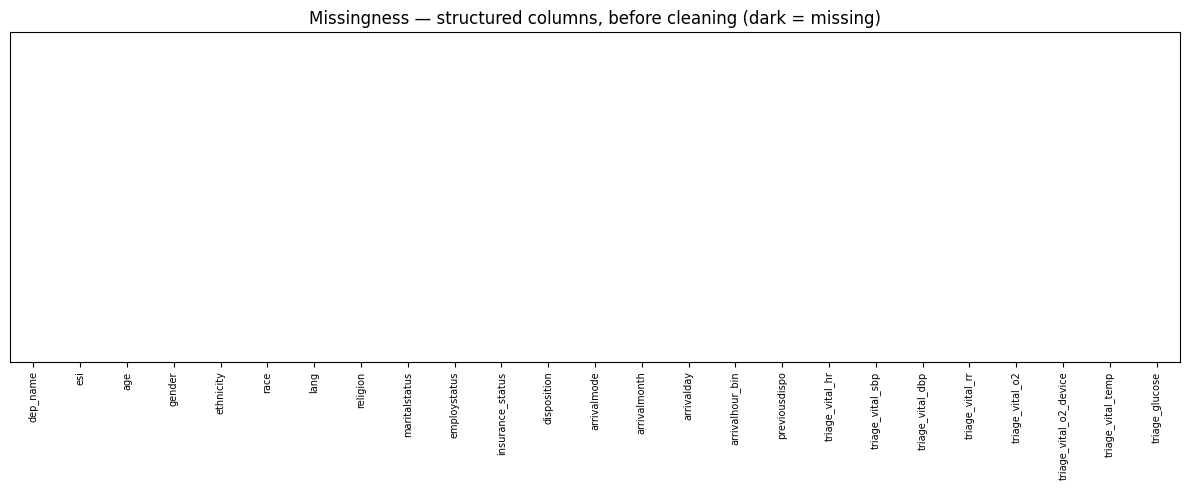

In [ ]:
#MISSINGNESS BEFORE CLEANING
grid = raw[structured].isna().values

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(grid, aspect="auto", cmap="gray_r")
ax.set_xticks(range(len(structured)))
ax.set_xticklabels(structured, rotation=90, fontsize=7)
ax.set_yticks([])
ax.set_title("Missingness — structured columns, before cleaning (dark = missing)")

plt.tight_layout()
plt.savefig("figs/01_missingness.png", dpi=110)
plt.show()


Visualizing missingness on the raw data (before cleaning) shows where the impossible values were concentrated. Compare this to the zero-missingness result in Section 4 to see the effect of the cleaning step.

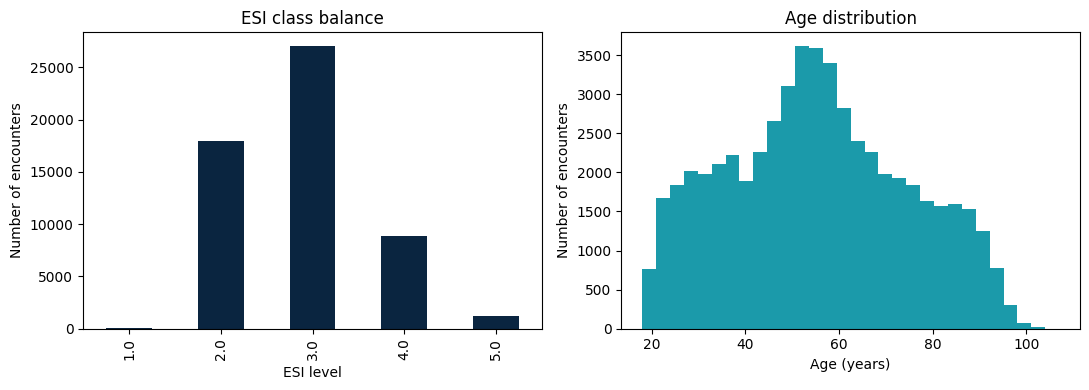

In [ ]:
#ESI CLASS BALANCE AND AGE DISTRIBUTION
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

esi_counts = df[TARGET].value_counts().sort_index()
esi_counts.plot.bar(ax=ax[0], color="#0A2540")
ax[0].set_title("ESI class balance")
ax[0].set_xlabel("ESI level")
ax[0].set_ylabel("Number of encounters")

ax[1].hist(df["age"].dropna(), bins=30, color="#1B9AAA")
ax[1].set_title("Age distribution")
ax[1].set_xlabel("Age (years)")
ax[1].set_ylabel("Number of encounters")

plt.tight_layout()
plt.savefig("figs/02_esi_age.png", dpi=110)
plt.show()


## 6 - Demographic distributions

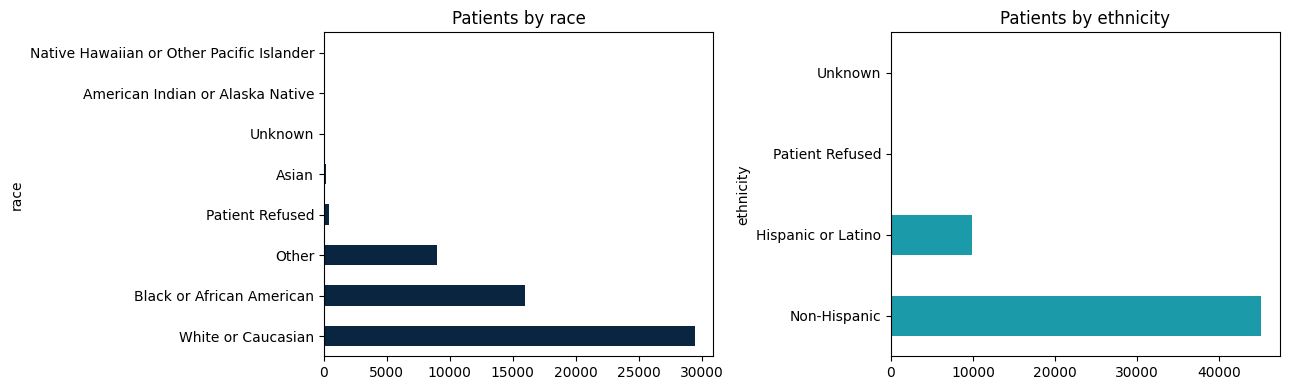

In [ ]:
#RACE AND ETHNICITY

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

df["race"].value_counts().plot.barh(ax=ax[0], color="#0A2540")
ax[0].set_title("Patients by race")

df["ethnicity"].value_counts().plot.barh(ax=ax[1], color="#1B9AAA")
ax[1].set_title("Patients by ethnicity")

plt.tight_layout()
plt.savefig("figs/03_demographics.png", dpi=110)
plt.show()


Race and ethnicity breakdowns are included here for cohort-representativeness checks only - both are excluded from LEAKAGE-style modeling considerations, and any fairness review would need a dedicated subgroup analysis beyond this notebook's scope.

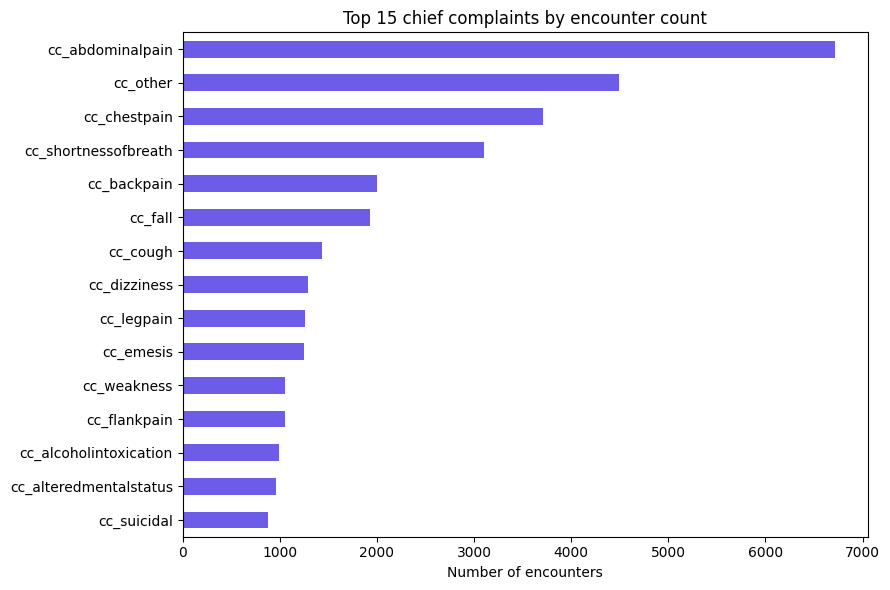

In [ ]:
#TOP 15 CHIEF COMPLAINTS
top_complaints = df[fam["chief_complaints"]].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top_complaints[::-1].plot.barh(ax=ax, color="#6C5CE7")
ax.set_title("Top 15 chief complaints by encounter count")
ax.set_xlabel("Number of encounters")

plt.tight_layout()
plt.savefig("figs/04_chief_complaints.png", dpi=110)
plt.show()


## 7 - Vitals vs. acuity

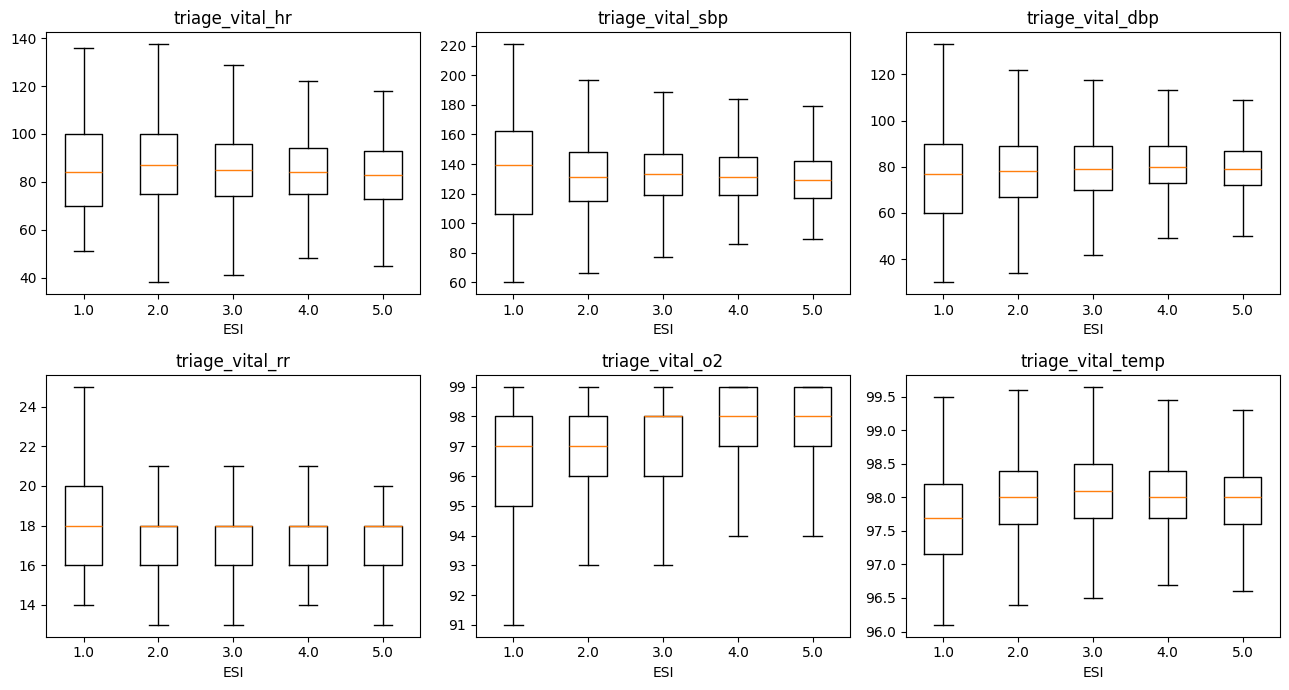

In [ ]:
#VITALS BY ESI LEVEL
esi_levels = sorted(df[TARGET].unique())
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for panel, col in zip(axes.ravel(), VITALS):
    groups_by_esi = [df.loc[df[TARGET] == level, col] for level in esi_levels]
    panel.boxplot(groups_by_esi, tick_labels=esi_levels, showfliers=False)
    panel.set_title(col)
    panel.set_xlabel("ESI")

plt.tight_layout()
plt.savefig("figs/05_vitals_by_esi.png", dpi=110)
plt.show()


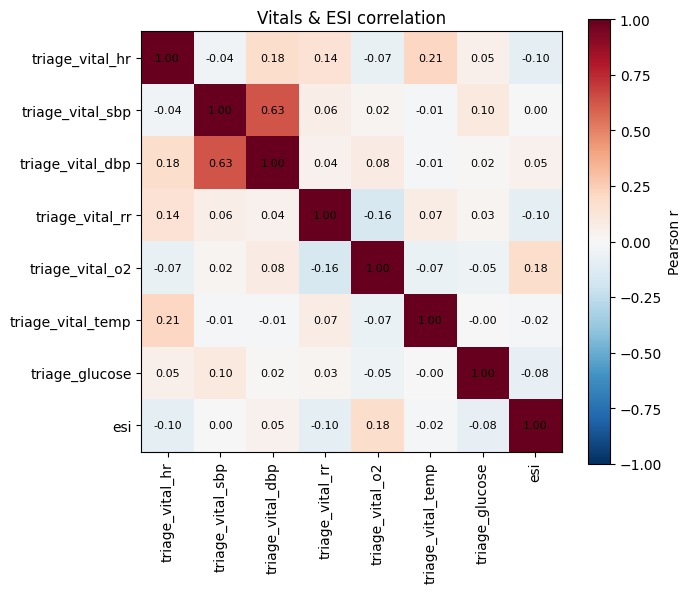

In [ ]:
#VITALS AND ESI CORRELATION HEATMAP
cols = fam["vitals"] + [TARGET]
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Vitals & ESI correlation")

plt.tight_layout()
plt.savefig("figs/06_correlation.png", dpi=110)
plt.show()


No single vital is strongly correlated with ESI on its own (all |r| well under 0.5), which is expected clinically - triage acuity is a judgment call combining multiple vitals and the chief complaint together, not a linear function of any one number.

In [ ]:
cc_corr = df[fam["chief_complaints"]].corrwith(df[TARGET]).sort_values()

print("Complaints most associated with HIGH acuity (negative r, toward ESI 1-2):")
print(cc_corr.head(8).round(3))

print("\nComplaints most associated with LOW acuity (positive r, toward ESI 4-5):")
print(cc_corr.tail(8).round(3))


Complaints most associated with HIGH acuity (negative r, toward ESI 1-2):
cc_chestpain               -0.164
cc_shortnessofbreath       -0.150
cc_suicidal                -0.143
cc_alcoholintoxication     -0.142
cc_alteredmentalstatus     -0.132
cc_psychiatricevaluation   -0.103
cc_weakness                -0.081
cc_syncope                 -0.075
dtype: float64

Complaints most associated with LOW acuity (positive r, toward ESI 4-5):
cc_motorvehiclecrash       0.095
cc_footpain                0.099
cc_suture/stapleremoval    0.105
cc_sorethroat              0.108
cc_kneepain                0.116
cc_dentalpain              0.127
cc_rash                    0.134
cc_backpain                0.142
dtype: float64


**Takeaway:** high-acuity complaints (chest pain, shortness of breath, suicidal ideation, altered mental status) skew toward ESI 1-2 as expected, while low-acuity complaints (sore throat, dental pain, rash) skew toward ESI 4-5. This gives an early sanity check that the chief-complaint flags carry real signal before any modeling begins.